<a href="https://colab.research.google.com/github/RobertsEshenvalds/test/blob/main/Copy_of_08_Exercise_02_RandomForest_RockOrMine_UNSOLVED_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 2 — Random Forest Classifier: Rock or Mine 🪨💣

**Dataset:** [Sonar — Rock or Mine Classification](https://www.kaggle.com/datasets/vijayaadithyanvg/rock-or-mine-classification)

The dataset contains **208 samples** of sonar signals bounced off either a **rock (R)** or a **metal cylinder / mine (M)**. Each sample has **60 numerical features** (energy in different frequency bands).

**Your task:** build a Random Forest classifier that predicts whether an object is a rock or a mine.

**Instructions:** Fill in every `___` gap, then run the cells.

---

## 0 · Install helper package (run once)

In [ ]:
# Run this cell once to install the UCI ML Repository helper
!pip install -q ucimlrepo

## 1 · Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

np.random.seed(42)

## 2 · Load the data

We load the dataset directly from the **UCI Machine Learning Repository** (dataset id 151).
The features are 60 sonar frequency-band energy readings; the target is `"R"` (rock) or `"M"` (mine).

> **Alternative:** if you downloaded the CSV from Kaggle, replace the cell below with:
> ```python
> df = pd.read_csv("sonar_data.csv", header=None)
> df.rename(columns={60: "target"}, inplace=True)
> ```


In [ ]:
from ucimlrepo import fetch_ucirepo

# Fetch Sonar (Mines vs. Rocks) — UCI id 151
dataset = fetch_ucirepo(id=151)

X_raw = dataset.data.features   # DataFrame, shape (208, 60)
y_raw = dataset.data.targets    # DataFrame, shape (208, 1)

# Combine into a single DataFrame for exploration
df = pd.concat([X_raw, y_raw], axis=1)
df.columns = [*range(60), "target"]

# Quick sanity check
print(f"Shape: {df.shape}")
df.head()

Shape: (208, 61)


,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,target
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


## 3 · Quick exploratory look

In [ ]:
# Class distribution
print(df["target"].value_counts())
print()
print(df.describe().T.head(10))

target
M    111
R     97
Name: count, dtype: int64

   count      mean       std     min       25%      50%       75%     max
0  208.0  0.029164  0.022991  0.0015  0.013350  0.02280  0.035550  0.1371
1  208.0  0.038437  0.032960  0.0006  0.016450  0.03080  0.047950  0.2339
2  208.0  0.043832  0.038428  0.0015  0.018950  0.03430  0.057950  0.3059
3  208.0  0.053892  0.046528  0.0058  0.024375  0.04405  0.064500  0.4264
4  208.0  0.075202  0.055552  0.0067  0.038050  0.06250  0.100275  0.4010
5  208.0  0.104570  0.059105  0.0102  0.067025  0.09215  0.134125  0.3823
6  208.0  0.121747  0.061788  0.0033  0.080900  0.10695  0.154000  0.3729
7  208.0  0.134799  0.085152  0.0055  0.080425  0.11210  0.169600  0.4590
8  208.0  0.178003  0.118387  0.0075  0.097025  0.15225  0.233425  0.6828
9  208.0  0.208259  0.134416  0.0113  0.111275  0.18240  0.268700  0.7106


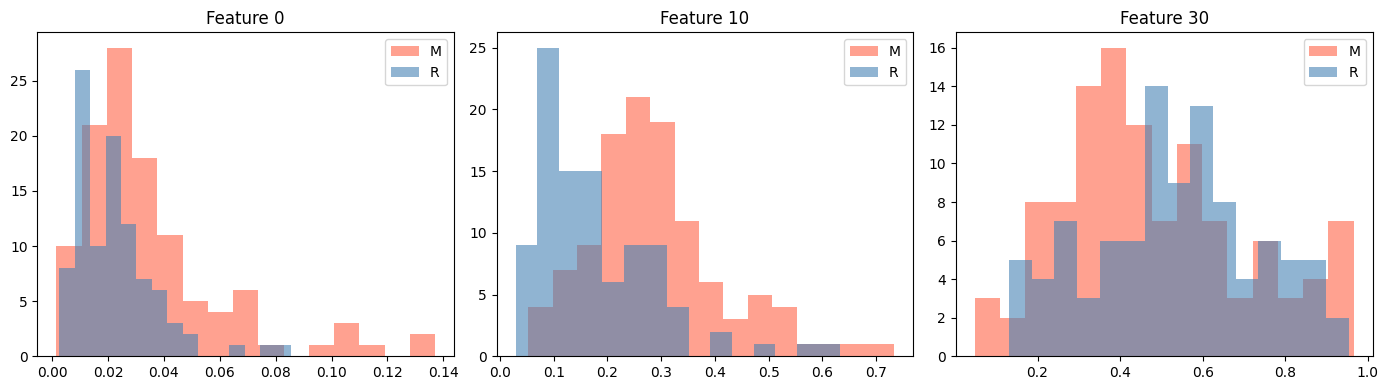

In [ ]:
# Visualise a few feature distributions by class
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate([0, 10, 30]):
  for label, color in zip(["M", "R"], ["tomato", "steelblue"]):
   axes[i].hist(
      df.loc[df["target"] == label, col],
     bins=15, alpha=0.6, label=label, color=color,
      )
  axes[i].set_title(f"Feature {col}")
  axes[i].legend()
plt.tight_layout()
plt.show()

## 4 · Prepare features and target

Separate the 60 sonar features (`X`) from the label column (`y`).


In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (208, 60)
y shape: (208,)


## 5 · Train / test split

Split the data — use **80 % train, 20 % test**, `random_state=42`, and **stratify** on `y`.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42,
stratify=y,
)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (166, 60) | Test: (42, 60)


## 6 · Train a Random Forest

Create a `RandomForestClassifier` and fit it on the training set.

Suggested starting hyper-parameters:
- `n_estimators=100`
- `random_state=42`


In [ ]:
rf = RandomForestClassifier(
  n_estimators=100,
  random_state=42,
)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## 7 · Make predictions

In [ ]:
y_pred = rf.predict(X_test)

## 8 · Evaluate the model

Print the **accuracy** and the full **classification report**, then display a **confusion matrix**.


In [ ]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8810

              precision    recall  f1-score   support

           M       0.81      1.00      0.90        22
           R       1.00      0.75      0.86        20

    accuracy                           0.88        42
   macro avg       0.91      0.88      0.88        42
weighted avg       0.90      0.88      0.88        42



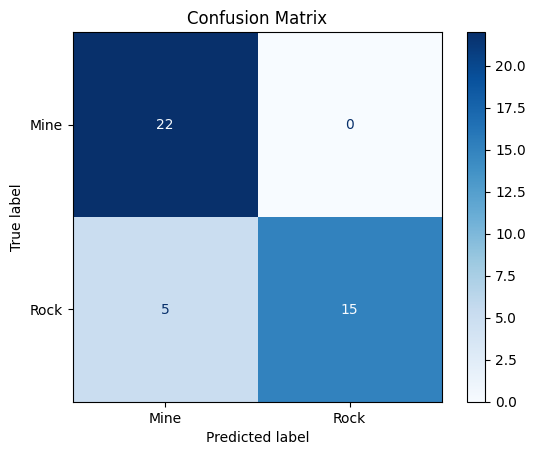

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=["M", "R"])
disp = ConfusionMatrixDisplay(cm, display_labels=["Mine", "Rock"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## 9 · Feature importance

Random Forest gives us feature importances for free. Plot the **top 15** most important features.


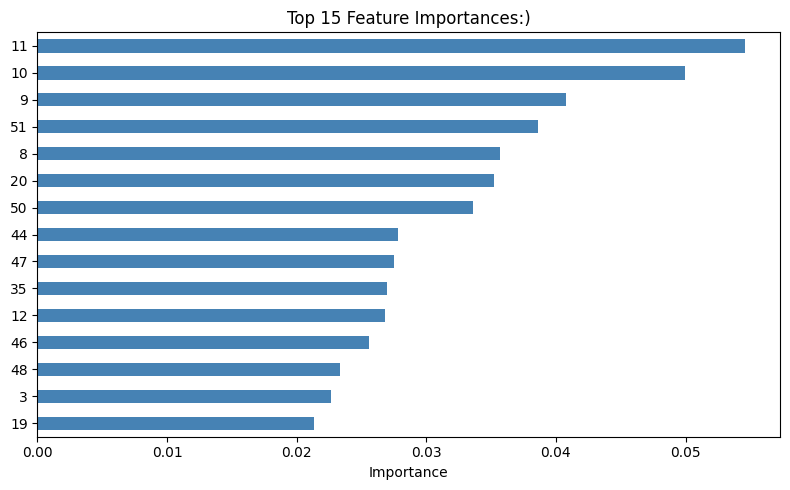

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top15 = importances.nlargest(15)

plt.figure(figsize=(8, 5))
top15.sort_values().plot.barh(color="steelblue")
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances:)")
plt.tight_layout()
plt.show()

## 10 · Bonus — Experiment 🧪

Try changing `n_estimators` or `max_depth` and see if you can improve the accuracy.


In [ ]:
rf2 = RandomForestClassifier(
  n_estimators=220,
  max_depth=10,
  random_state=42,
)
rf2.fit(X_train, y_train)
y_pred2 = rf2.predict(X_test)

---
✅ **Done!** You've trained and evaluated a Random Forest on the Sonar dataset.